<a href="https://colab.research.google.com/github/samuelglezact-oss/Rendimiento_Academico/blob/main/02_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelo de regresión múltiple: Rendimiento académico en Universitarios**

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.compat import lzip
import scipy.stats as stats
from sklearn.metrics import r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importamos la base de datos
df = pd.read_excel('/content/drive/MyDrive/Econometría 1/df_Final.xlsx')
df

,Edad,Area_Academica,Hrs de Sueño,Ingreso_Mensual,Tiempo_Traslado_Min,Transporte,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,...,Promedio,Nivel de estres,Metodo de estudio,Nivel de interes,Area de interes,Categoria_Predominante,Transp_a_pie,Transp_por_app,Transp_publico,Transp_propio
0,22,Exactas e Ingenierías,8,42400,7.5,A pie,0,2,2,5,...,8.70,3,0,3,Probabilidad y estadística,Exactas y Métodos,1,0,0,0
1,21,Exactas e Ingenierías,8,16960,52.5,"Transporte público (Autobús, Metro, etc.)",0,4,1,3,...,7.00,4,1,3,Matemáticas,Exactas y Métodos,0,0,1,0
2,23,Exactas e Ingenierías,8,42400,30.0,Vehículo propio (Automóvil/Motocicleta),0,4,1,2,...,9.25,1,0,4,Finanzas,Exactas y Métodos,0,0,0,1
3,20,Artes y Diseño,8,16960,52.5,"Transporte público (Autobús, Metro, etc.)",0,2,2,5,...,9.00,4,0,5,Comunicación,Diseño y Artes,0,0,1,0
4,21,Artes y Diseño,5,8480,30.0,"Transporte público (Autobús, Metro, etc.)",0,2,1,2,...,8.34,5,0,3,Artes,Diseño y Artes,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,20,Salud y Naturales,6,16960,75.0,"Transporte público (Autobús, Metro, etc.)",0,2,4,3,...,8.00,3,0,5,Salud,Salud y Biológicas,0,0,1,0
147,21,Artes y Diseño,6,25440,7.5,Vehículo propio (Automóvil/Motocicleta),0,3,0,4,...,9.60,4,0,4,Diseño gráfico,Diseño y Artes,0,0,0,1
148,21,Salud y Naturales,6,42400,30.0,Vehículo propio (Automóvil/Motocicleta),1,2,2,2,...,9.40,3,1,5,Salud,Salud y Biológicas,0,0,0,1
149,22,Sociales y Humanidades,7,16960,52.5,"Transporte por aplicación (Uber, Didi, Taxi)",1,3,1,3,...,8.20,5,1,5,Finanzas,Económico-Administrativa,0,1,0,0


In [ ]:
#Se hace una limpieza para poder hacer estadistica descriptiva de las variables escogidas.
df_1 = df.drop(['Edad', 'Ingreso_Mensual', 'Area_Academica', 'Transporte', 'Metodo de estudio','Promedio', 'Area de interes',
         'Categoria_Predominante','Transp_a_pie','Nivel de interes', 'Transp_por_app', 'Transp_publico','Transp_propio'],axis=1)
df_1

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
0,8,7.5,0,2,2,5,4,3
1,8,52.5,0,4,1,3,5,4
2,8,30.0,0,4,1,2,6,1
3,8,52.5,0,2,2,5,4,4
4,5,30.0,0,2,1,2,9,5
...,...,...,...,...,...,...,...,...
146,6,75.0,0,2,4,3,6,3
147,6,7.5,0,3,0,4,7,4
148,6,30.0,1,2,2,2,6,3
149,7,52.5,1,3,1,3,6,5


In [ ]:
#Hacemos estadística descriptiva de cada variable, sacando la media, desviación estandar, mímino, máximo, y cuartiles de las variables explicativas.
df_1.describe()

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,6.364238,40.480132,0.258278,2.748344,2.059603,3.192053,6.145695,3.701987
std,1.098383,32.032165,0.439144,0.793461,1.255557,1.304941,1.546598,0.957738
min,3.000000,7.500000,0.000000,1.000000,0.000000,1.000000,4.000000,1.000000
25%,6.000000,7.500000,0.000000,2.000000,1.000000,2.000000,5.000000,3.000000
50%,6.000000,30.000000,0.000000,3.000000,2.000000,3.000000,6.000000,4.000000
75%,7.000000,52.500000,1.000000,3.000000,3.000000,4.000000,7.000000,4.000000
max,8.000000,135.000000,1.000000,5.000000,5.000000,5.000000,9.000000,5.000000


# **Gráficos de comparación cada variable explicativa con la varibale dependiente (Promedio)**

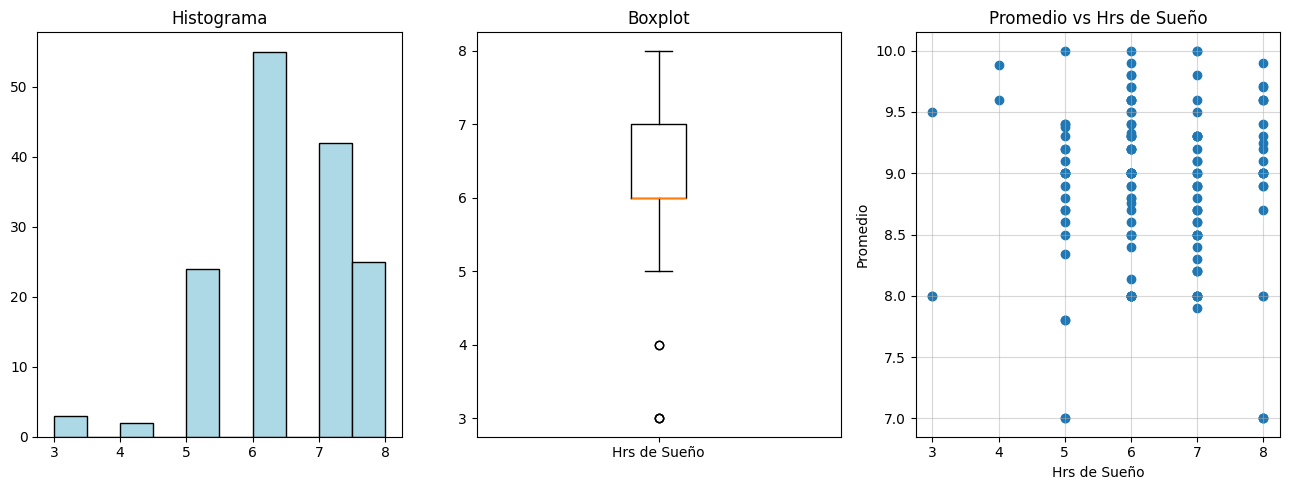

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE SUEÑO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))

ax[0].hist(df_1['Hrs de Sueño'], color='lightblue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de Sueño'].dropna(), tick_labels=['Hrs de Sueño'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de Sueño'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs de Sueño')
ax[2].set_xlabel('Hrs de Sueño')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7092/479666456.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Tiempo_Traslado_Min'].dropna(), labels=['Tiempo_Traslado_Min'])


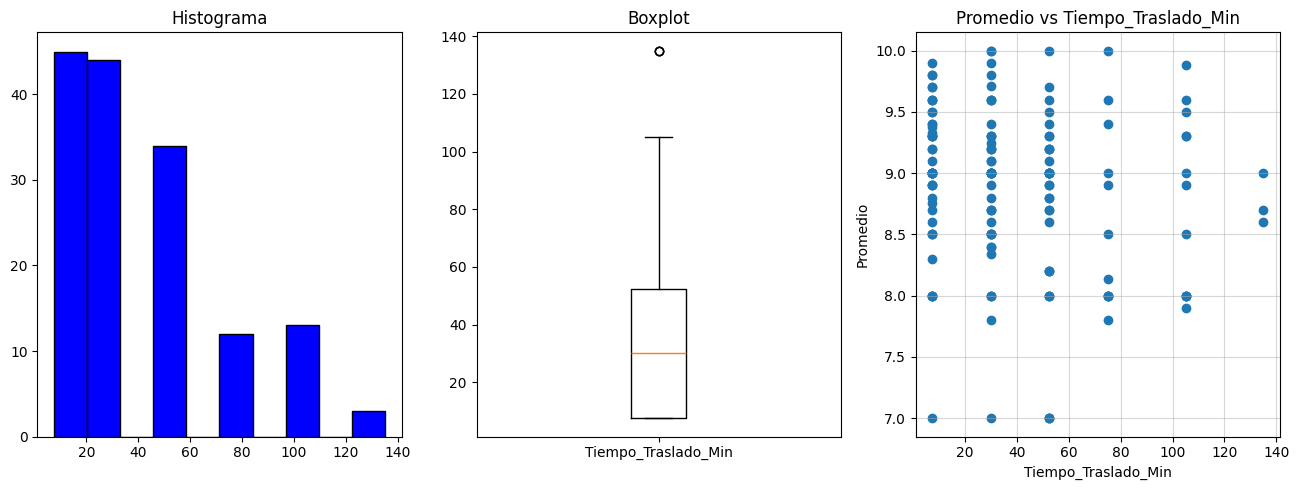

In [ ]:
#Comparamos las diferentes gráficas de la variable "TIEMPO DE TRASLADO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Tiempo_Traslado_Min'], color='blue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Tiempo_Traslado_Min'].dropna(), labels=['Tiempo_Traslado_Min'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Tiempo_Traslado_Min'], df['Promedio'])
ax[2].set_title('Promedio vs Tiempo_Traslado_Min')
ax[2].set_xlabel('Tiempo_Traslado_Min')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

Esta sesgado a la izquierda, se podria usar una trasnformación logarítmica para que el unico dato que esta en 140 no afecte a la variable en general  

/tmp/ipykernel_7092/1220959988.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Número de comidas'].dropna(), labels=['Número de comidas'])


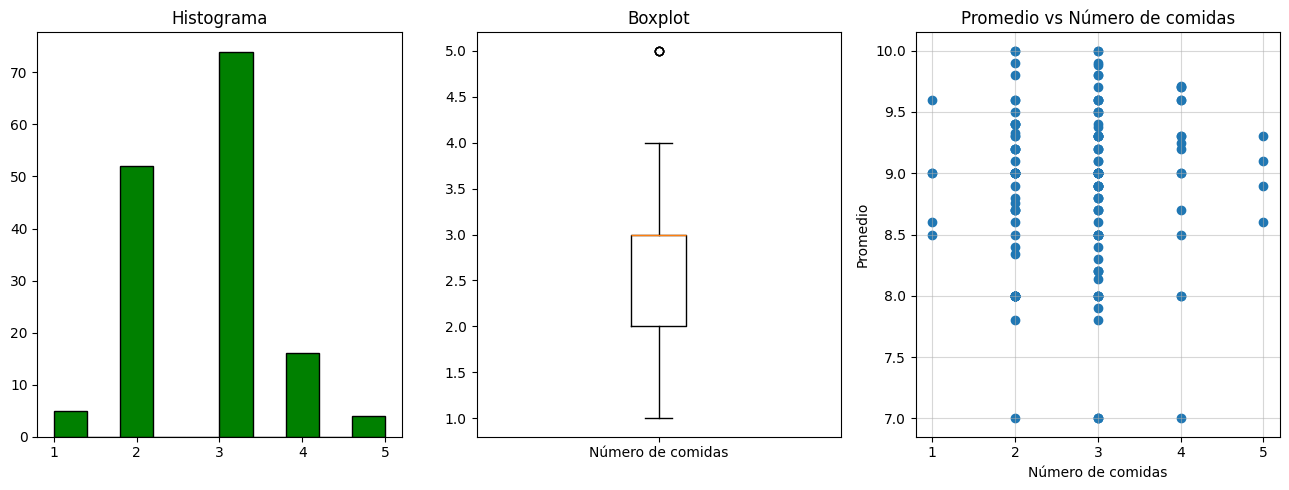

In [ ]:
#Comparamos las diferentes gráficas de la variable "NÚMERO DE COMIDAS"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Número de comidas'], color='green', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Número de comidas'].dropna(), labels=['Número de comidas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Número de comidas'], df['Promedio'])
ax[2].set_title('Promedio vs Número de comidas')
ax[2].set_xlabel('Número de comidas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_556/2371934452.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Hrs de estudio'].dropna(), labels=['Hrs de estudio'])


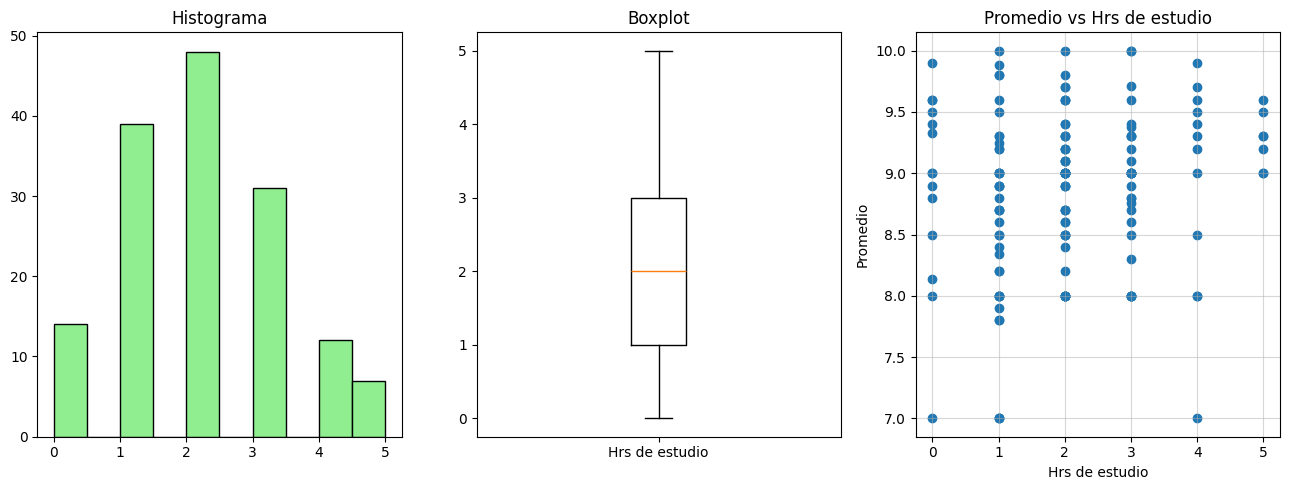

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE ESTUDIO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs de estudio'], color='lightgreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de estudio'].dropna(), labels=['Hrs de estudio'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de estudio'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs de estudio')
ax[2].set_xlabel('Hrs de estudio')
ax[2].set_ylabel('Promedio')


plt.tight_layout()
plt.show()

El grafico de puntos nos puede indicar que existe una probable heteroscedasticidad, pues se puede apreciar una forma de abanico, de derecha a izquierda

/tmp/ipykernel_7092/3214550069.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Hrs en Redes'].dropna(), labels=['Hrs en Redes'])


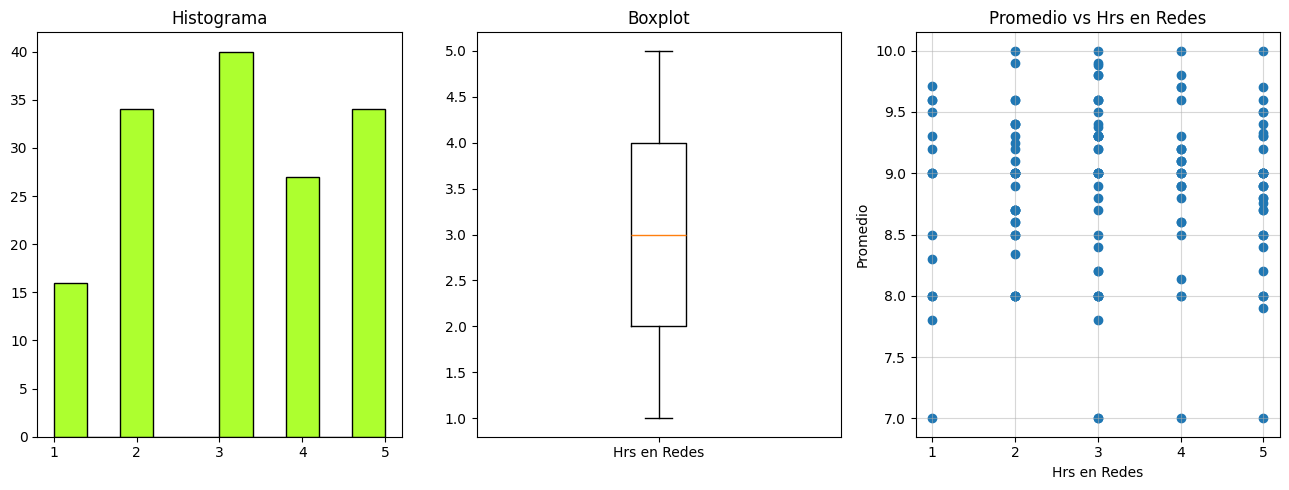

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS EN REDES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs en Redes'], color='greenyellow', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs en Redes'].dropna(), labels=['Hrs en Redes'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs en Redes'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs en Redes')
ax[2].set_xlabel('Hrs en Redes')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

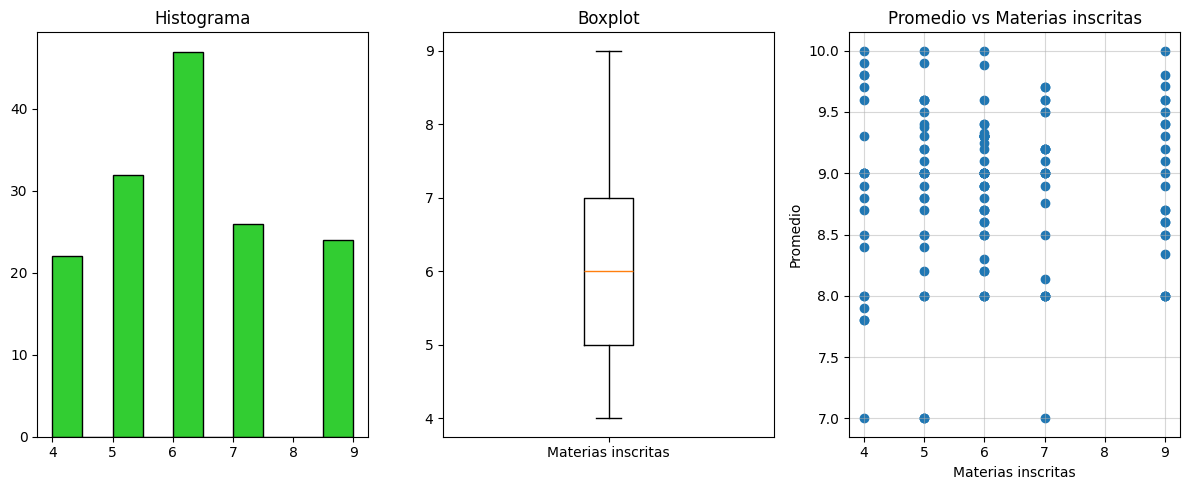

In [ ]:
#Comparamos las diferentes gráficas de la variable "MATERIAS INSCRITAS"
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].hist(df_1['Materias inscritas'], color='limegreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Materias inscritas'].dropna(), tick_labels=['Materias inscritas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Materias inscritas'], df['Promedio'])
ax[2].set_title('Promedio vs Materias inscritas')
ax[2].set_xlabel('Materias inscritas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7092/61035835.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Nivel de estres'].dropna(), labels=['Nivel de estres'])


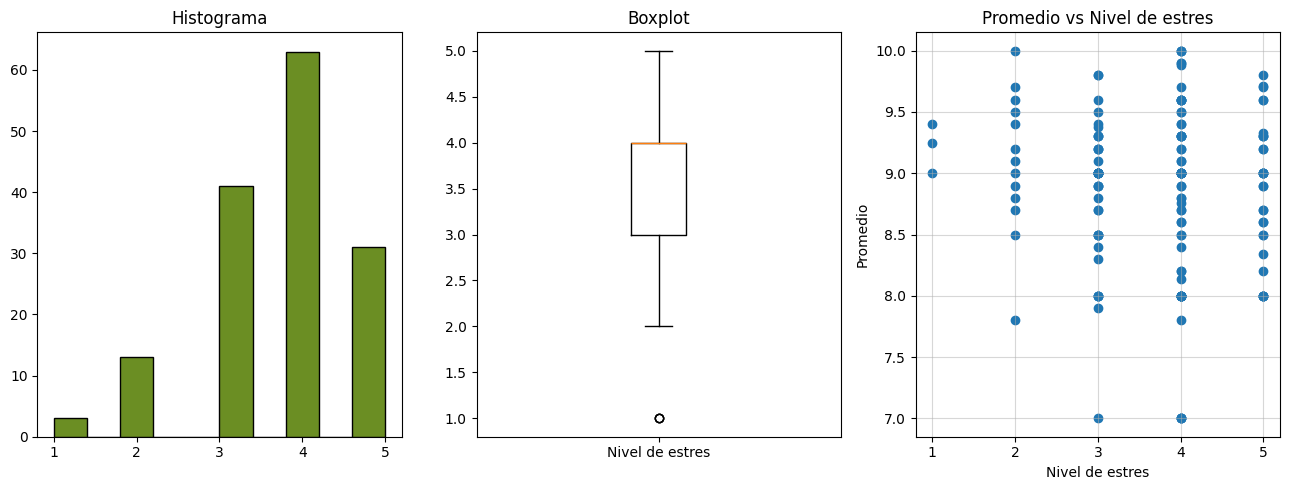

In [ ]:
#Comparamos las diferentes gráficas de la variable "NIVEL DE ESTRES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Nivel de estres'], color='olivedrab', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Nivel de estres'].dropna(), labels=['Nivel de estres'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Nivel de estres'], df['Promedio'])
ax[2].set_title('Promedio vs Nivel de estres')
ax[2].set_xlabel('Nivel de estres')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

Muestra un "outlier". Hay alguien con estrés nivel 1 que es una excepción estadística en la muestra.

# **Pruebas para detectar problemas: multicolinealidad, heteroscedasticidad y pruebas individuales**

In [ ]:
#Vemos posible correlación entre variables explicativas
df_1.corr()

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
Hrs de Sueño,1.000000,-0.122009,-0.127229,0.190020,-0.156037,-0.025874,-0.200198,-0.206656
Tiempo_Traslado_Min,-0.122009,1.000000,-0.062192,0.072983,-0.005689,-0.004214,0.038613,0.154638
Trabajo,-0.127229,-0.062192,1.000000,-0.118344,-0.076470,-0.191837,0.081646,0.057420
Número de comidas,0.190020,0.072983,-0.118344,1.000000,0.001773,-0.017397,-0.160063,-0.090574
Hrs de estudio,-0.156037,-0.005689,-0.076470,0.001773,1.000000,-0.076205,0.074461,0.164558
Hrs en Redes,-0.025874,-0.004214,-0.191837,-0.017397,-0.076205,1.000000,-0.109751,-0.092589
Materias inscritas,-0.200198,0.038613,0.081646,-0.160063,0.074461,-0.109751,1.000000,0.227541
Nivel de estres,-0.206656,0.154638,0.057420,-0.090574,0.164558,-0.092589,0.227541,1.000000


No se encontro correlación alta en las variables explicativas

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
#Calculamos el VIF de cada variable para ver multicolinealidad
x = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,114.942718
1,Hrs de Sueño,1.156309
2,Trabajo,1.090833
3,Hrs de estudio,1.069467
4,Hrs en Redes,1.070453
5,Nivel de estres,1.135295
6,Materias inscritas,1.110913
7,Tiempo_Traslado_Min,1.054850
8,Número de comidas,1.078337


No se encontro multicolinealidad en ninguna variable, la constante suele ser común pero no afecta en nuestro modelo, ni en las demás variables

In [ ]:
#Verificamos si existen outliers en nuestros datos
vars_modelo = ['Promedio','Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes',
               'Nivel de estres','Materias inscritas','Tiempo_Traslado_Min',
               'Número de comidas']
def detectar_outliers_iqr(data, columnas):
    resumen = []
    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        resumen.append([col, lower, upper, n_outliers])
    return pd.DataFrame(resumen, columns=['Variable','Límite inferior','Límite superior','N_outliers'])

outliers = detectar_outliers_iqr(df, vars_modelo)
outliers

,Variable,Límite inferior,Límite superior,N_outliers
0,Promedio,7.3,10.5,5
1,Hrs de Sueño,4.5,8.5,5
2,Trabajo,-1.5,2.5,0
3,Hrs de estudio,-2.0,6.0,0
4,Hrs en Redes,-1.0,7.0,0
5,Nivel de estres,1.5,5.5,3
6,Materias inscritas,2.0,10.0,0
7,Tiempo_Traslado_Min,-60.0,120.0,3
8,Número de comidas,0.5,4.5,4


In [ ]:
# Generamos el primer modelo, tomando 8 variables de nuestra base de datos.
y = df['Promedio']
X = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.328
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.234
Time:                        04:42:20   Log-Likelihood:                -144.72
No. Observations:                 151   AIC:                             307.4
Df Residuals:                     142   BIC:                             334.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   8.6407      0.568     15.222      0.000       7.519       9.763
Hrs de Sueño           -0.0095      0.052     -0.183      0.855      -0.112       0.093
Trabajo                 0.0718      0.126      0.568      0.571      -0.178       0.322
Hrs de estudio          0.0867      0.044      1.982      0.049       0.000       0.173
Hrs en Redes            0.0260      0.042      0.617      0.538      -0.057       0.109
Nivel de estres        -0.0690      0.059     -1.167      0.245      -0.186       0.048
Materias inscritas      0.0356      0.036      0.983      0.327      -0.036       0.107
Tiempo_Traslado_Min    -0.0031      0.002     -1.825      0.070      -0.006       0.000
Número de comidas       0.0622      0.070      0.895      0.373      -0.075       0.200
==============================================================================
Omnibus:                        9.830   Durbin-Watson:                   1.902
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                9.981
Skew:                          -0.546   Prob(JB):                      0.00680
Kurtosis:                       3.627   Cond. No.                         563.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Como no existe multicolinealidad se pueden hacer pruebas t
print(model.params)
print(model.tvalues)
print(model.pvalues)

const                  8.640706
Hrs de Sueño          -0.009504
Trabajo                0.071799
Hrs de estudio         0.086726
Hrs en Redes           0.025998
Nivel de estres       -0.068987
Materias inscritas     0.035589
Tiempo_Traslado_Min   -0.003108
Número de comidas      0.062193
dtype: float64
const                  15.221650
Hrs de Sueño           -0.182745
Trabajo                 0.568269
Hrs de estudio          1.982048
Hrs en Redes            0.617256
Nivel de estres        -1.167275
Materias inscritas      0.983012
Tiempo_Traslado_Min    -1.824752
Número de comidas       0.894539
dtype: float64
const                  1.231535e-31
Hrs de Sueño           8.552586e-01
Trabajo                5.707499e-01
Hrs de estudio         4.940423e-02
Hrs en Redes           5.380543e-01
Nivel de estres        2.450555e-01
Materias inscritas     3.272733e-01
Tiempo_Traslado_Min    7.014023e-02
Número de comidas      3.725473e-01
dtype: float64


De acuerdo con las pruebas t, las variables horas de estudio y materias inscritas resultaron significativas. Igualmente, el tiempo de traslado mostró un efecto negativo significativo al 10%. El resto de las variables no presentaron evidencia suficiente para explicar la variable dependiente.

Text(0.5, 1.0, 'Residuos vs Ajustados')

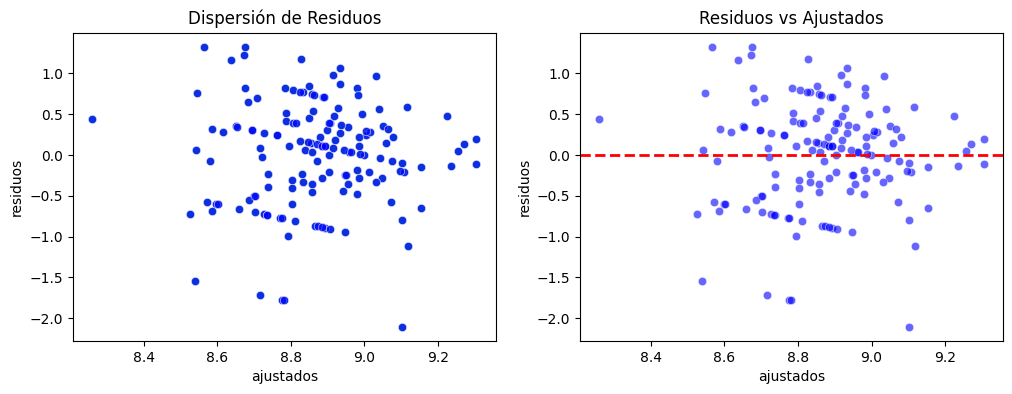

In [ ]:
#Gráfico de errores

df["ajustados"] = model.fittedvalues  #Obtener los valores estimados
df["residuos"] = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[0])

sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[0], color="blue", alpha=0.6)
axes[0].set_title("Dispersión de Residuos")

sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[1], color="blue", alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--", lw=2) # Línea roja discontinua en el origen
axes[1].set_title("Residuos vs Ajustados")



In [ ]:
#Prueba para saber si los errores siguen una distribución normal
from scipy.stats import shapiro

stat, p = shapiro(df['residuos'])
print("p-value:", p)

p-value: 0.009872534076826986


Ya que p-value es menor que 0.05 los errores no siguen una distribución normal. La falta de normalidad en los residuos puede afectar la validez de los intervalos de confianza y las pruebas de significancia, ya que estos se basan en supuestos de normalidad. En particular, los intervalos podrían no reflejar correctamente la incertidumbre de los estimadores.

In [ ]:
#Prueba Breusch–Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(8.80298327523867), 'LM p-value': np.float64(0.3591878338719044), 'F Statistic': np.float64(1.0988483213957438), 'F p-value': np.float64(0.3675530238815836)}


Con esta pruebatenemos que esos pocos puntos que pudimos ver en los graficos anteriores, no tienen la fuerza suficiente para sesgar los errores estándar de todo el grupo, por lo que no presenta heteroscedasticidad

In [ ]:
#Prueba Ramsey RESET
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model, power=2, use_f=True)
print(reset_test)

<F test: F=0.0639207242491457, p=0.8007712924662959, df_denom=141, df_num=1>


# **Transformación del modelo base**

In [ ]:
#Transfromación box cox
lambda_opt = stats.boxcox_normmax(y, brack=(-2, 2))  # búsqueda en un rango razonable
y_bc, lambda_used = stats.boxcox(y, lmbda=lambda_opt), lambda_opt

X_bc = sm.add_constant(X)
model_bc = sm.OLS(y_bc, X_bc).fit()

print(f"=== MODELO BOX–COX (λ óptimo = {lambda_used:.3f}) ===")
print(model_bc.summary(), "\n")

=== MODELO BOX–COX (λ óptimo = 4.689) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.141
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.340
Time:                        04:32:55   Log-Likelihood:                -1353.3
No. Observations:                 151   AIC:                             2725.
Df Residuals:                     142   BIC:                             2752.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [ ]:
#Transformación log-lineal
y_log= np.log(y)
x_log= sm.add_constant(X)
model_log = sm.OLS(y_log, x_log).fit()

print(" === MODELO LOG-LINEAL: ln(y)===")
print(model_log.summary(), "\n")

 === MODELO LOG-LOG: ln(y)===
                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.356
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.221
Time:                        04:34:07   Log-Likelihood:                 179.87
No. Observations:                 151   AIC:                            -341.7
Df Residuals:                     142   BIC:                            -314.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

In [ ]:
#Transformación LOG-LOG
yloglog= np.log(y)
xloglog=np.log(X)

model_log=sm.OLS(yloglog,sm.add_constant(X)). fit()
model_log.summary()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.356
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.221
Time:                        04:34:50   Log-Likelihood:                 179.87
No. Observations:                 151   AIC:                            -341.7
Df Residuals:                     142   BIC:                            -314.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.1508      0.066     32.513      0.000       2.020       2.282
Hrs de Sueño           -0.0010      0.006     -0.170      0.865      -0.013       0.011
Trabajo                 0.0093      0.015      0.633      0.527      -0.020       0.038
Hrs de estudio          0.0103      0.005      2.017      0.046       0.000       0.020
Hrs en Redes            0.0032      0.005      0.661      0.510      -0.006       0.013
Nivel de estres        -0.0083      0.007     -1.198      0.233      -0.022       0.005
Materias inscritas      0.0044      0.004      1.050      0.296      -0.004       0.013
Tiempo_Traslado_Min    -0.0004      0.000     -1.793      0.075      -0.001    3.64e-05
Número de comidas       0.0070      0.008      0.865      0.389      -0.009       0.023
==============================================================================
Omnibus:                       19.284   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.117
Skew:                          -0.783   Prob(JB):                     5.80e-06
Kurtosis:                       4.175   Cond. No.                         563.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#**Modelos alternativos**

In [ ]:
y = df['Promedio']
X = df[['Hrs de Sueño','Hrs de estudio','Número de comidas']]
X = sm.add_constant(X)
model_1= sm.OLS(y, X).fit()
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.280
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.283
Time:                        04:41:39   Log-Likelihood:                -148.22
No. Observations:                 151   AIC:                             304.4
Df Residuals:                     147   BIC:                             316.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.5855      0.365     23.535      0.000       7.865       9.306
Hrs de Sueño          0.0010      0.050      0.021      0.983      -0.098       0.100
Hrs de estudio        0.0793      0.043      1.839      0.068      -0.006       0.164
Número de comidas     0.0413      0.069      0.601      0.549      -0.094       0.177
==============================================================================
Omnibus:                       11.558   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.898
Skew:                          -0.647   Prob(JB):                      0.00261
Kurtosis:                       3.467   Cond. No.                         51.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y = df['Promedio']
X = df[['Nivel de estres','Tiempo_Traslado_Min','Hrs en Redes','Trabajo']]
X = sm.add_constant(X)
model_2= sm.OLS(y, X).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.156
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.333
Time:                        20:32:26   Log-Likelihood:                -147.81
No. Observations:                 151   AIC:                             305.6
Df Residuals:                     146   BIC:                             320.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.0851      0.268     33.842      0.000       8.555       9.616
Nivel de estres        -0.0405      0.057     -0.713      0.477      -0.153       0.072
Tiempo_Traslado_Min    -0.0031      0.002     -1.810      0.072      -0.006       0.000
Hrs en Redes            0.0146      0.042      0.349      0.727      -0.068       0.097
Trabajo                 0.0429      0.124      0.345      0.731      -0.203       0.289
==============================================================================
Omnibus:                       12.307   Durbin-Watson:                   1.839
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.863
Skew:                          -0.653   Prob(JB):                      0.00161
Kurtosis:                       3.580   Cond. No.                         266.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y = df['Promedio']
X = df[['Materias inscritas']]
X = sm.add_constant(X)

model_3 = sm.OLS(y, X).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.4832
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.488
Time:                        20:32:26   Log-Likelihood:                -149.92
No. Observations:                 151   AIC:                             303.8
Df Residuals:                     149   BIC:                             309.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.7205      0

# **Dummys**

In [ ]:
y = df['Promedio']
X = df[['Hrs de estudio','Transp_publico','Transp_propio','Transp_a_pie']]
X = sm.add_constant(X)
model_4 = sm.OLS(y, X).fit()
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     2.496
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0453
Time:                        04:36:33   Log-Likelihood:                -145.17
No. Observations:                 151   AIC:                             300.3
Df Residuals:                     146   BIC:                             315.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.2490      0.336     24.573      0.000       7.586       8.912
Hrs de estudio     0.0782      0.042      1.841      0.068      -0.006       0.162
Transp_publico     0.3815      0.329      1.159      0.248      -0.269       1.032
Transp_propio      0.5851      0.343      1.704      0.090      -0.093       1.264
Transp_a_pie       0.6256      0.343      1.822      0.070      -0.053       1.304
==============================================================================
Omnibus:                        9.428   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.009   Jarque-Bera (JB):                9.377
Skew:                          -0.583   Prob(JB):                      0.00920
Kurtosis:                       3.362   Cond. No.                         32.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Variables un poco mas significativas que todas las demás